In [6]:
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting_5 import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import ICIW_Plots
import numpy as np
import torch

plt.style.use(["ICIWstyle", "ICIWlatex"])

In [7]:
run_id = "ct7rqhxz"
name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
model = RTDModule.load_from_checkpoint(ckpt_path)
# model.net.conv_layers[0].set_to_direct_response()

E1 = model.net.E[0].numpy()
E2 = model.net.E[1].numpy()
E3 = model.net.E[2].numpy()
E4 = model.net.E[3].numpy()
t1 = model.net.conv_layers[0].t_kernel.detach().numpy()
t2 = model.net.conv_layers[1].t_kernel.detach().numpy()
t3 = model.net.conv_layers[2].t_kernel.detach().numpy()
t4 = model.net.conv_layers[3].t_kernel.detach().numpy()

wandb:   1 of 1 files downloaded.  


In [8]:
print(I1 := np.trapz(E1, t1))
print(I2 := np.trapz(E2, t2))
print(I3 := np.trapz(E3, t3))


print(I4 := np.trapz(E4, t4))


print(I1 * I2 * I3 * I4)

0.99826145
0.95642036
0.99593216
0.9073383
0.86276424


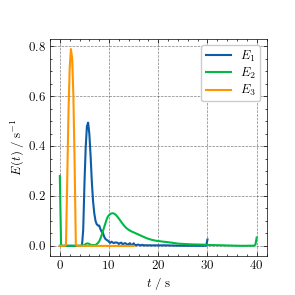

In [15]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$E(t)\;/\;\unit{\per\second}$",
)
ax.plot(t1, E1, label="$E_1$")
ax.plot(t2, E2, label="$E_2$")
ax.plot(t3, E3, label="$E_3$")
# ax.plot(t4, E4, label="$E_4$")
ax.legend()

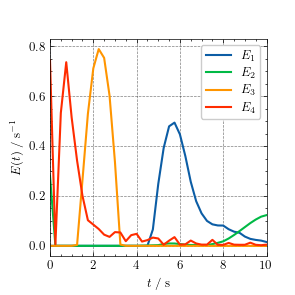

In [10]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$E(t)\;/\;\unit{\per\second}$",
    xlim=(0, 10),
    # ylim=(-0.01, 0.01),
)
ax.plot(t1, E1, label="$E_1$")
ax.plot(t2, E2, label="$E_2$")
ax.plot(t3, E3, label="$E_3$")
ax.plot(t4, E4, label="$E_4$")
ax.legend()

# load the low pressure experiment

In [11]:
run_id = "g7gu2iek"
name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
model = RTDModule.load_from_checkpoint(ckpt_path)
# model.net.conv_layers[0].set_to_direct_response()

lp_E3 = model.net.E[2].numpy()
lp_t3 = model.net.conv_layers[2].t_kernel.detach().numpy()

wandb:   1 of 1 files downloaded.  


<>:11: SyntaxWarning: invalid escape sequence '\q'
<>:12: SyntaxWarning: invalid escape sequence '\q'
<>:11: SyntaxWarning: invalid escape sequence '\q'
<>:12: SyntaxWarning: invalid escape sequence '\q'
C:\Users\Hannes\AppData\Local\Temp\ipykernel_13296\2072120389.py:11: SyntaxWarning: invalid escape sequence '\q'
  ax.plot(t3, E3, label="$E_3$ at $\qty{1e5}{\pascal}$")
C:\Users\Hannes\AppData\Local\Temp\ipykernel_13296\2072120389.py:12: SyntaxWarning: invalid escape sequence '\q'
  ax.plot(lp_t3, lp_E3, label="$E_3$ at $\qty{4e5}{\pascal}$")


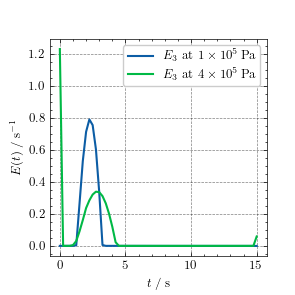

In [14]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$E(t)\;/\;\unit{\per\second}$",
    # xlim=(0, 10),
    # ylim=(-0.01, 0.01),
)
ax.plot(t3, E3, label="$E_3$ at $\qty{1e5}{\pascal}$")
ax.plot(lp_t3, lp_E3, label="$E_3$ at $\qty{4e5}{\pascal}$")
ax.legend()